In [1]:
# https://www.kaggle.com/datasets/tawfikelmetwally/employee-dataset/data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize, StandardScaler
import glob
import os
from pathlib import Path
import gradio as gr

In [2]:
def read_all_files(folder_path):
    
    all_dataframes = []
 
    pattern = os.path.join(folder_path, "data_part_*.*")
    file_paths = glob.glob(pattern)
    
    for file_path in sorted(file_paths): 
        try:
            file_ext = Path(file_path).suffix.lower()
            file_name = os.path.basename(file_path)
            
            if file_ext == '.csv':
                df = pd.read_csv(file_path)
            elif file_ext in '.xlsx':
                df = pd.read_excel(file_path)
            elif file_ext == '.parquet':
                df = pd.read_parquet(file_path)

            all_dataframes.append(df)
            
        except Exception as e:
            print(f"Ошибка при чтении {file_path}: {e}")
    
    if all_dataframes:
        combined_df = pd.concat(all_dataframes, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()

folder = "D:/Education/Data Analysis/classic_ML_shift/train_data"
result_df = read_all_files(folder)

In [3]:
data_clean = pd.read_csv('train_data/df_train_clean.csv', index_col=0)
X_test_base = pd.read_csv('X_test.csv')
X_test_base['Test'] = 'Yes'
df = pd.concat([data_clean, result_df],ignore_index=True)
df_n = pd.concat([df, X_test_base], ignore_index=True) # объединяем X_train, X_test, чтобы в дальнейшем бинарные признаки из train были доступны в test

### Разведочный анализ данных

In [ ]:
X_test_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2488 entries, 0 to 2487
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Год_рождения         2488 non-null   int64  
 1   Подписаны_документы  0 non-null      float64
 2   Пол                  2488 non-null   object 
 3   БылПростой           2488 non-null   object 
 4   ОпытВДолжности       2488 non-null   int64  
 5   Активность           2488 non-null   int64  
 6   Знак_зодиака         2488 non-null   object 
 7   Возраст              2488 non-null   int64  
 8   Оценка_HR            2488 non-null   int64  
 9   УровеньОплаты        2488 non-null   int64  
 10  Офлайн_участие       2488 non-null   int64  
 11  Образование          2488 non-null   object 
 12  Телефон              2488 non-null   int64  
 13  Город                2488 non-null   object 
 14  Размер               2488 non-null   object 
 15  Закрытые_проекты     2488 non-null   i

In [ ]:
X_test_base.describe()

,Год_рождения,Подписаны_документы,ОпытВДолжности,Активность,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Телефон,Закрытые_проекты,ГодНайма,Курсы
count,2488.000000,0.0,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2.488000e+03,2488.000000,2488.000000,2488.000000
mean,1995.036174,NaN,2.642685,253.721463,30.975080,4.961013,2.640273,0.506431,9.154979e+11,7.544212,2015.095257,2.554662
std,5.170310,NaN,1.618568,145.646810,5.104948,3.134771,0.622279,0.500059,2.617966e+09,4.498811,1.892616,1.318662
min,1984.000000,NaN,0.000000,0.000000,22.000000,0.000000,1.000000,0.000000,9.110026e+11,0.000000,2012.000000,1.000000
25%,1991.000000,NaN,1.000000,125.000000,27.000000,2.000000,2.000000,0.000000,9.132943e+11,4.000000,2013.000000,1.000000
50%,1996.000000,NaN,2.000000,257.500000,30.000000,5.000000,3.000000,1.000000,9.153837e+11,7.000000,2015.000000,2.000000
75%,1999.000000,NaN,4.000000,375.000000,35.000000,8.000000,3.000000,1.000000,9.177702e+11,11.000000,2017.000000,3.000000
max,2005.000000,NaN,7.000000,500.000000,41.000000,10.000000,3.000000,1.000000,9.199992e+11,15.000000,2018.000000,5.000000


Заметно, что у признака Подписаны_документы отсутствуют данные в тестовой выборке, следовательно, его можно исключить из анализа обучающей выборки

#### Чистый дата сет

In [80]:
data_clean.describe()

,Год_рождения,ОпытВДолжности,Активность,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Телефон,Закрытые_проекты,ГодНайма,Курсы,Увольнение
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,3.000000e+01,30.000000,30.000000,30.000000,30.000000
mean,1994.700000,3.000000,249.233333,31.333333,4.966667,2.766667,0.433333,9.157456e+11,6.966667,2015.433333,2.533333,0.433333
std,4.850524,1.575677,138.626933,4.978113,3.045441,0.430183,0.504007,2.164656e+09,4.715955,1.794308,1.074255,0.504007
min,1987.000000,0.000000,23.000000,24.000000,0.000000,2.000000,0.000000,9.123588e+11,0.000000,2012.000000,1.000000,0.000000
25%,1989.250000,2.000000,145.250000,27.000000,3.000000,3.000000,0.000000,9.141050e+11,2.250000,2014.000000,2.000000,0.000000
50%,1996.000000,2.500000,220.500000,30.000000,5.000000,3.000000,0.000000,9.149604e+11,7.500000,2016.000000,3.000000,0.000000
75%,1998.000000,4.750000,343.250000,36.750000,8.000000,3.000000,1.000000,9.175250e+11,10.000000,2017.000000,3.000000,1.000000
max,2002.000000,5.000000,498.000000,40.000000,9.000000,3.000000,1.000000,9.199109e+11,15.000000,2018.000000,5.000000,1.000000


In [ ]:
data_clean.groupby('Увольнение').median(numeric_only=True)

,Год_рождения,ОпытВДолжности,Активность,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Телефон,Закрытые_проекты,ГодНайма,Курсы
Увольнение,,,,,,,,,,,
0,1997.0,3.0,321.0,29.0,6.0,3.0,0.0,9.149248e+11,9.0,2015.0,3.0
1,1996.0,2.0,148.0,31.0,3.0,3.0,1.0,9.149959e+11,5.0,2016.0,2.0


#### Общий дата сет

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8357 entries, 0 to 8356
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Год_рождения         6712 non-null   float64
 1   Подписаны_документы  6716 non-null   object 
 2   Пол                  6671 non-null   object 
 3   БылПростой           6710 non-null   object 
 4   ОпытВДолжности       6689 non-null   float64
 5   Активность           6698 non-null   float64
 6   Знак_зодиака         6670 non-null   object 
 7   Возраст              6671 non-null   float64
 8   Оценка_HR            6695 non-null   float64
 9   УровеньОплаты        6678 non-null   float64
 10  Офлайн_участие       6698 non-null   float64
 11  Образование          6677 non-null   object 
 12  Телефон              8357 non-null   object 
 13  Город                6662 non-null   object 
 14  Размер               6709 non-null   object 
 15  Закрытые_проекты     6719 non-null   f

In [34]:
df.isna().sum()/df.shape[0]

Год_рождения           0.196841
Подписаны_документы    0.196362
Пол                    0.201747
БылПростой             0.197080
ОпытВДолжности         0.199593
Активность             0.198516
Знак_зодиака           0.201867
Возраст                0.201747
Оценка_HR              0.198875
УровеньОплаты          0.200909
Офлайн_участие         0.198516
Образование            0.201029
Телефон                0.000000
Город                  0.202824
Размер                 0.197200
Закрытые_проекты       0.196003
ГодНайма               0.198636
Курсы                  0.201747
Увольнение             0.000000
dtype: float64

In [91]:
df.describe(include = 'object')

,Подписаны_документы,Пол,БылПростой,Знак_зодиака,Образование,Телефон,Город,Размер
count,6716,6671,6710,6670,6677,8357,6662,6709
unique,2,2,2,12,3,2789,3,6
top,Нет,Male,No,Рак,Bachelors,912358763109,Bangalore,M
freq,4207,3729,5837,702,4770,6,2829,2403


In [5]:
with pd.ExcelWriter("describe data.xlsx") as writer:
    X_test_base.describe().to_excel(writer, sheet_name='X_test')
    df.describe().to_excel(writer, sheet_name='df_num')
    df.describe(include = 'object').to_excel(writer, sheet_name='df_str')

In [ ]:
df.groupby(['Увольнение','Город'], as_index=False)['Город'].count()

Увольнение  Город    
0           Bangalore    1825
            New Delhi    1264
            Pune          986
1           Bangalore    1004
            New Delhi     619
            Pune          964
Name: Город, dtype: int64

In [46]:
df.groupby(['Увольнение','Образование'])['Образование'].count()

Увольнение  Образование
0           Bachelors      2993
            Masters         801
            PHD             289
1           Bachelors      1777
            Masters         709
            PHD             108
Name: Образование, dtype: int64

In [47]:
df.groupby(['Увольнение','Пол'])['Пол'].count()

Увольнение  Пол   
0           Female    1490
            Male      2587
1           Female    1452
            Male      1142
Name: Пол, dtype: int64

In [48]:
df.groupby(['Увольнение','БылПростой'])['БылПростой'].count()

Увольнение  БылПростой
0           No            3582
            Yes            498
1           No            2255
            Yes            375
Name: БылПростой, dtype: int64

In [ ]:
df.groupby(['Увольнение','Знак_зодиака'])['Знак_зодиака'].count()

Увольнение  Знак_зодиака
0           Близнецы        331
            Весы            299
            Водолей         333
            Дева            319
            Козерог         334
            Лев             297
            Овен            348
            Рак             424
            Рыбы            327
            Скорпион        336
            Стрелец         366
            Телец           336
1           Близнецы        247
            Весы            213
            Водолей         234
            Дева            171
            Козерог         261
            Лев             200
            Овен            201
            Рак             278
            Рыбы            216
            Скорпион        181
            Стрелец         212
            Телец           206
Name: Знак_зодиака, dtype: int64

In [65]:
df.groupby(['Увольнение','Размер'])['Размер'].count()

Увольнение  Размер
0           L         1131
            M         1442
            S          745
            XL         493
            XS         165
            XXL        131
1           L          625
            M          961
            S          573
            XL         195
            XS         154
            XXL         94
Name: Размер, dtype: int64

Text(0.5, 1.0, 'Количество пропусков в строке')

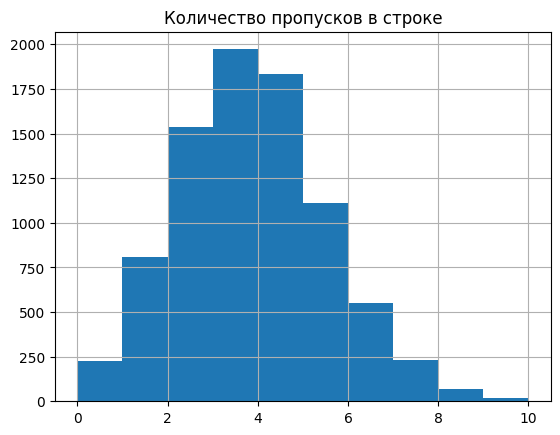

In [42]:
df.isna().sum(axis=1).hist()
plt.title('Количество пропусков в строке')

<Axes: >

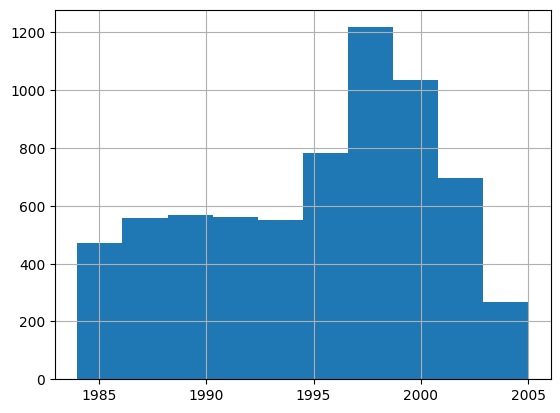

In [43]:
df['Год_рождения'].hist()

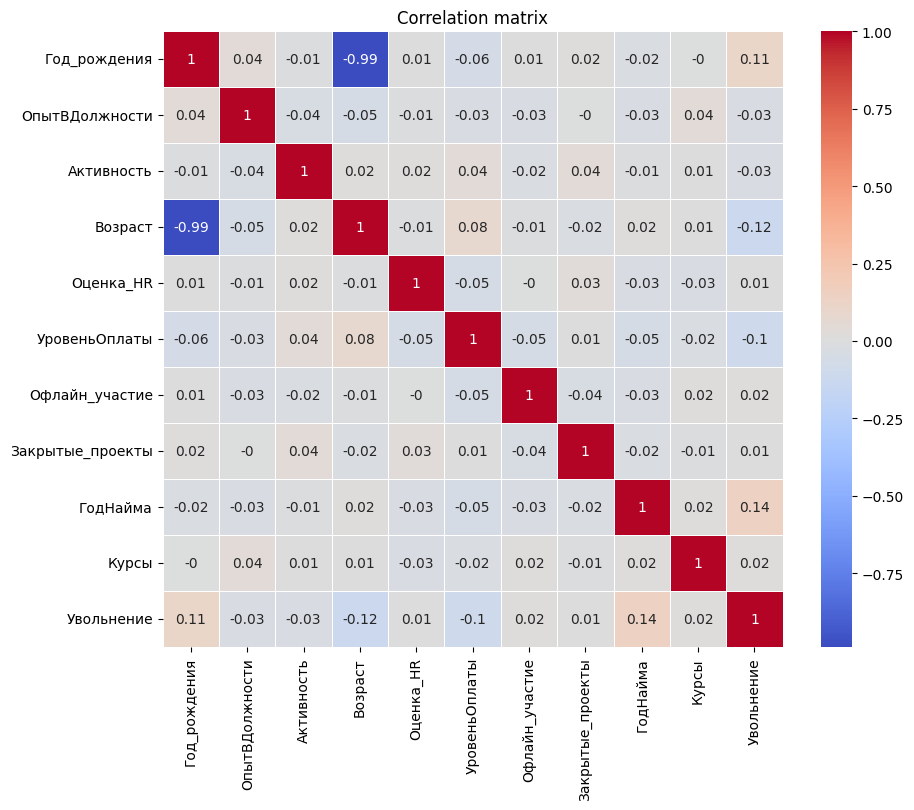

In [44]:
plt.figure(figsize = (10,8))

# sns.set(font_scale=1)
cols_num = list(df.select_dtypes(exclude='object').columns)

corr_matrix = df[cols_num].corr()
corr_matrix = np.round(corr_matrix, 2)
sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap='coolwarm')

plt.title('Correlation matrix')
plt.show()

Видно, что Год_рождения сильно коррелирует с возрастом, поэтому Год_рождения можно исключить

<Axes: >

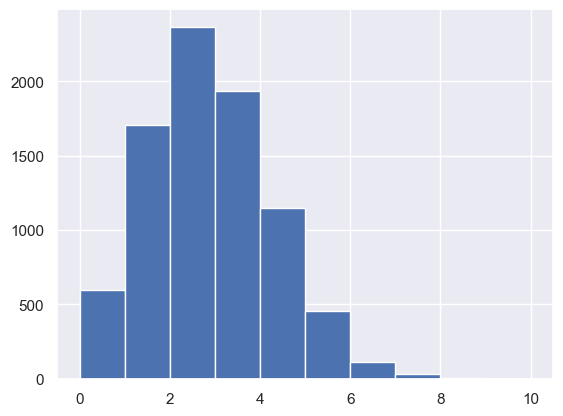

In [37]:
df_upd.isna().sum(axis=1).hist()

In [116]:
df[(df['УровеньОплаты'] < 3) & (df['Увольнение'] == 0)].shape[0]/df.shape[0]*100

10.93693909297595

На boxplots видно, что уровень оплаты ниже 3 у оставшихся в компании сотрудников - это выбросы на фоне остальных данных.

Но при этом - 11% обучающей выборки. Ниже показаны результаты по двум построенным моделям, в одной данные об этих сотрудниках сохранены, в другой исключены

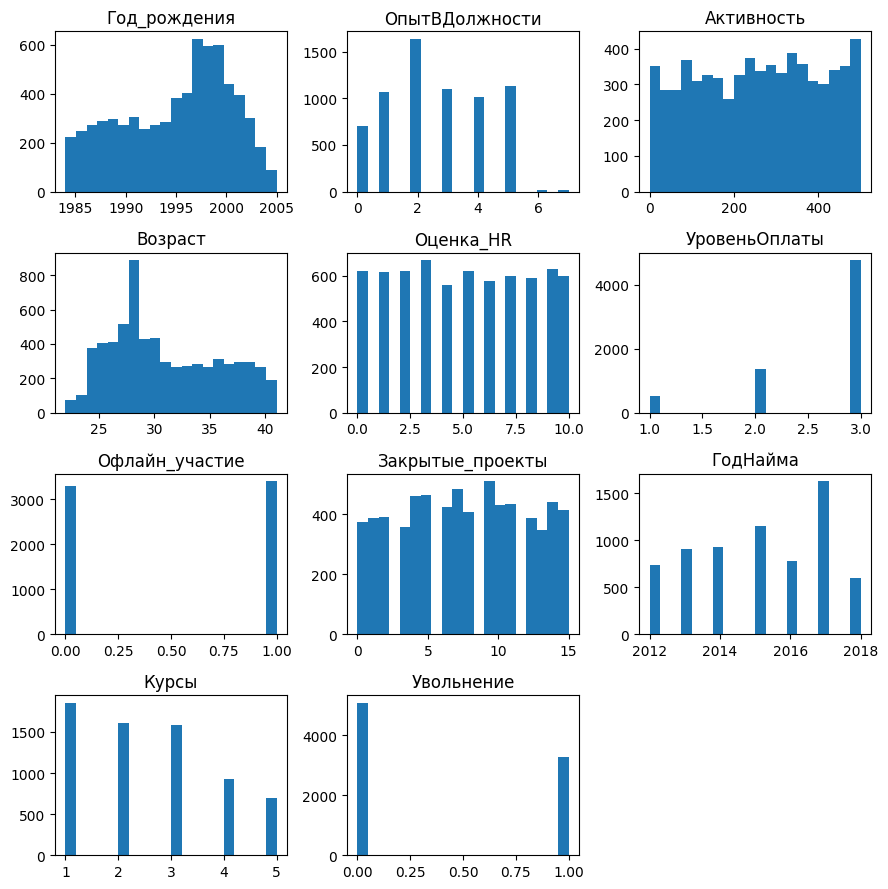

In [29]:
df.hist(figsize=(9,9), bins=20, grid=False)
plt.tight_layout()

In [ ]:
df['Телефон'].astype('str').nunique() # Номер телефона не дает информацию о потенциальном уволнении

2764

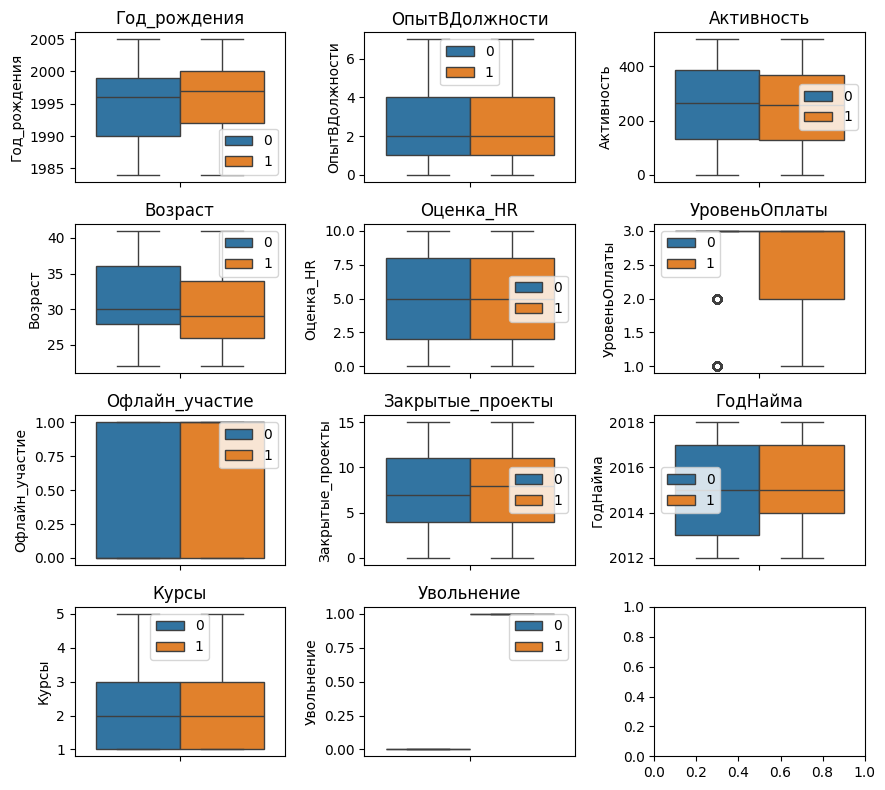

In [27]:
n_cols = 3

df_filtr = df[cols_num].copy()
n_rows = math.ceil(len(df_filtr.columns) / n_cols) # math.ceil округляет число в большую сторону

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(9, 8))
axes = axes.flatten()

for i, column in enumerate(df_filtr.columns):
    sns.boxplot(df, y = column, hue = 'Увольнение',ax=axes[i])
    axes[i].set_title(column)
    axes[i].legend()

plt.tight_layout()
plt.show()

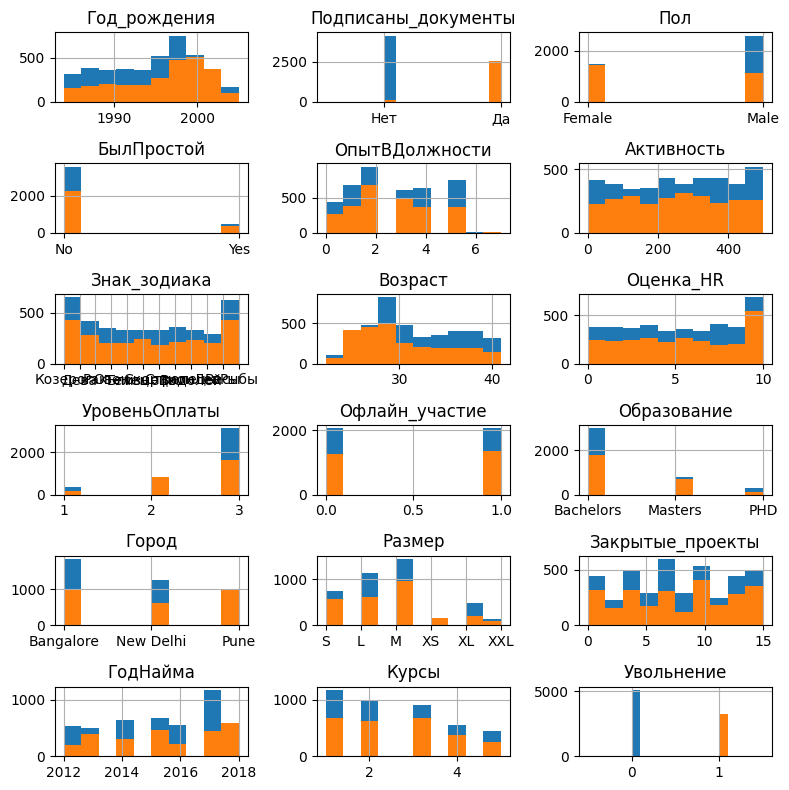

In [30]:
n_cols = 3

to_keep = [item for item in df.columns if item not in ['Телефон']]
df_filtr = df[to_keep].copy()
n_rows = math.ceil(len(df_filtr.columns) / n_cols) # math.ceil округляет число в большую сторону

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(8, 8))
axes = axes.flatten()

for i, column in enumerate(df_filtr.columns):
    df_filtr[df_filtr['Увольнение'] == 0][column].hist(ax=axes[i])
    df_filtr[df_filtr['Увольнение'] == 1][column].hist(ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

Знаки Зодиака и Размер одежды - не являются признаками оценки увольнения.  
БылПростой - признак, у которого значений Yes кратно больше чем No для обоих классов y, что не дает большой изменчивости, поэтому признак исключается. Были построены модели RandomForest с учетом этого признака и без него. Модель без БылПростой показала лучший ROC-AUC = 0.96, а модель с БылПростой ROC-AUC = 0.92. 

По результатам EDA были определены ключевые признаки для построения модели:
* Числовые: 'ОпытВДолжности', 'Активность', 'Возраст', 'Оценка_HR', 'УровеньОплаты',
       'Офлайн_участие', 'Закрытые_проекты','ГодНайма', 'Курсы'
* Категориальные: 'Образование', 'Город','Пол'

### Предобработка данных

Предобработка включала в себя: 
1. Отбор признаков по результатам EDA
2. Добавление бинарных признаков для пола, города и образования
3. Фильтр df по условиям: в каждой строке не больше 3 пропусков и отсутствие пропусков у признаков типа object
4. Сплит X, y в соотношеннии 70/30
5. Заполнение пропусков у числовых признаков медианной в зависимости от целевой переменной

In [37]:
# отбираем признаки по результатам EDA
X_features = list(df.select_dtypes(exclude=['object']).columns[:-1])
X_feat_l = [item for item in X_features if item not in ['Год_рождения']] + ['Test','Образование','Город','Пол']
X = df_n[X_feat_l]
y = df['Увольнение']

X[['Пол_Female','Образование_Bachelors','Образование_Masters','Город_Bangalore','Город_New Delhi']] = pd.get_dummies(df_n[['Пол', 'Образование','Город']], dtype=int)[['Пол_Female','Образование_Bachelors','Образование_Masters','Город_Bangalore','Город_New Delhi']]

X_data = X[X['Test'] != 'Yes'].copy()
X_test = X[X['Test'] == 'Yes'].copy()
X_data.drop(columns='Test',inplace=True)
X_test.drop(columns='Test',inplace=True)
df_upd = X_data.copy()
df_upd['target'] = y
cols_obj = sorted(X_data.select_dtypes(include=['object']).columns)
df_filtr = df_upd[(df_upd.isna().sum(axis=1) <= 3) & (~(df_upd[cols_obj].isna().any(axis=1)))].reset_index(drop=True)
                #   & (~((df_upd['УровеньОплаты'] < 3) & (df_upd['target'] == 0)))].reset_index(drop=True)
X_upd = df_filtr.iloc[:,:-1]
y_upd = df_filtr.iloc[:,-1]

X_train, X_valid, y_train, y_valid = train_test_split(X_upd, y_upd, test_size=0.3, random_state=42)

df_train = X_train.copy()
df_train['target'] = y_train
df_valid = X_valid.copy()
df_valid['target'] = y_valid
df_g = df_train.groupby('target',as_index=False).median(numeric_only=True)
cols_num = list(X_train.select_dtypes(exclude=['object']).columns)

# Обработка пропусков медианной в зависимости от target

category_dict = {category: group.drop('target', axis=1) 
                 for category, group in df_g.groupby('target')}

category_full_dict = {}
for category, group in df_g.groupby('target'):
    group_dict = group.drop('target', axis=1).to_dict('records')[0]
    category_full_dict[category] = group_dict

def fill_by_complex_dict(df, fill_dict):
    df_filled = df.copy()
    
    for category, col_dict in fill_dict.items():
        mask = df_filled['target'] == category
        
        for col, fill_value in col_dict.items():
            if col in df_filled.columns:
                col_mask = mask & df_filled[col].isnull()
                df_filled.loc[col_mask, col] = fill_value
    
    return df_filled

res_train = fill_by_complex_dict(df_train, category_full_dict)
res_valid = fill_by_complex_dict(df_valid, category_full_dict)

X_train[cols_num] = res_train[cols_num]
X_valid[cols_num] = res_valid[cols_num]
X_test[cols_num] = X_test[cols_num]
X_train.columns

C:\Users\User\AppData\Local\Temp\ipykernel_1956\3217384282.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Пол_Female','Образование_Bachelors','Образование_Masters','Город_Bangalore','Город_New Delhi']] = pd.get_dummies(df_n[['Пол', 'Образование','Город']], dtype=int)[['Пол_Female','Образование_Bachelors','Образование_Masters','Город_Bangalore','Город_New Delhi']]
C:\Users\User\AppData\Local\Temp\ipykernel_1956\3217384282.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Пол_Female','Образован

Index(['ОпытВДолжности', 'Активность', 'Возраст', 'Оценка_HR', 'УровеньОплаты',
       'Офлайн_участие', 'Закрытые_проекты', 'ГодНайма', 'Курсы',
       'Образование', 'Город', 'Пол', 'Пол_Female', 'Образование_Bachelors',
       'Образование_Masters', 'Город_Bangalore', 'Город_New Delhi'],
      dtype='object')

### Построение моделей

In [7]:
# Функция для оценки модели
def evaluate_model(model, X_train, X_valid, y_train, y_valid):
    model.fit(X_train, y_train)
    y_tp_c = model.predict_proba(X_train)[:, 1]
    y_vp_c = model.predict_proba(X_valid)[:, 1]
    ROC_AUC_p = roc_auc_score(y_train, y_tp_c)
    ROC_AUC_v = roc_auc_score(y_valid, y_vp_c)
    return ROC_AUC_p, ROC_AUC_v

#### Logistic Regression

In [145]:
# Стандартизация
scaler = StandardScaler()
X_train_stand = scaler.fit_transform(X_train[cols_num])
X_valid_stand = scaler.transform(X_valid[cols_num])

# Обучение модели
clf_reg = LogisticRegression(random_state=42)
clf_reg.fit(X_train_stand, y_train)
print(
    f'Train: {roc_auc_score(y_train, clf_reg.predict_proba(X_train_stand)[:, 1])}\n'
    f'valid: {roc_auc_score(y_valid, clf_reg.predict_proba(X_valid_stand)[:, 1])}\n'
)

# Предсказание вероятностей
# probabilities = clf_reg.predict_proba(X_test)[:, 1]

Train: 0.7420406000182704
valid: 0.713043872234388



#### Random Forest (Финальная модель с ROC-AUC 0.92 на лидерборде)

In [ ]:
#Обучение модели
max_d = 20
n_est = 300
max_f = 0.7

clf_forest = RandomForestClassifier(max_depth=max_d, n_estimators=n_est, oob_score=True, max_features=max_f, random_state=42)
clf_forest.fit(X_train[cols_num], y_train)

y_tp_f = clf_forest.predict_proba(X_train[cols_num])[:, 1]
y_vp_f = clf_forest.predict_proba(X_valid[cols_num])[:, 1]

print(
    f'Train: {roc_auc_score(y_train, y_tp_f)}\n'
    f'valid: {roc_auc_score(y_valid, y_vp_f)}\n'
)

# Предсказание вероятностей
probabilities = clf_forest.predict_proba(X_test[cols_num])[:, 1]

Train: 1.0
valid: 0.9580442497923431



#### Gradio inference

In [87]:
def predict_forest(exp, act, age, hr_gr, grade, offline, projects, emp_year, courses, edu, city, gender):
    # Входные данные -> DataFrame
    input_data = pd.DataFrame([[exp, act, age, hr_gr, grade, offline, projects, emp_year, courses, edu, city, gender]], 
                            columns=X_train.columns[:-5])
    
    # Предсказание
    input_data['Пол_Female'] = input_data.apply(lambda x: 1 if x['Пол'] == 'Female' else 0, axis=1)
    input_data['Образование_Bachelors'] = input_data.apply(lambda x: 1 if x['Образование'] == 'Bachelors' else 0, axis=1)
    input_data['Образование_Masters'] = input_data.apply(lambda x: 1 if x['Образование'] == 'Masters' else 0, axis=1)
    input_data['Город_Bangalore'] = input_data.apply(lambda x: 1 if x['Город'] == 'Bangalore' else 0, axis=1)
    input_data['Город_New Delhi'] = input_data.apply(lambda x: 1 if x['Город'] == 'New Delhi' else 0, axis=1)
    input_data = input_data[cols_num]
    prediction = clf_forest.predict(input_data)[0]
    result = 'Уволится' if prediction else 'Не уволится'
    
    # Вероятности для каждого класса
    proba = clf_forest.predict_proba(input_data)[:,prediction][0]
    
    
    return f"Вид: {result} (Уверенность: {proba:.2f})"

In [88]:
predict_forest(2, 100, 25, 1, 2, 1, 4, 2014, 3,'PHD','Bangalore','Female')

'Вид: Не уволится (Уверенность: 0.61)'

In [89]:
# Описание входных полей
edu = list(X_train['Образование'].unique())
city = list(X_train['Город'].unique())
gender = list(X_train['Пол'].unique())

inputs = [
    gr.Slider(0, 10, step=1, label="ОпытВДолжности"),
    gr.Slider(0, 500, step=1, label="Активность"),
    gr.Slider(20, 50, step=1, label="Возраст"),
    gr.Slider(0, 10, step=1, label="Оценка HR"),
    gr.Slider(1, 3, step=1, label="УровеньОплаты"),
    gr.Checkbox(label="Офлайн_участие"),
    gr.Slider(0, 20, step=1, label="Закрытые_проекты"),
    gr.Slider(2010, 2020, step=1, label="ГодНайма"),
    gr.Slider(1, 5, step=1, label="Курсы"),
    gr.Dropdown(choices=edu,label="Образование"),
    gr.Dropdown(choices=city,label="Город"),
    gr.Dropdown(choices=gender,label="Пол")
]

# Заголовок и примеры
title = "Классификация увольнения"

# Создание интерфейса
demo = gr.Interface(
    fn=predict_forest,
    inputs=inputs,
    outputs="text",
    title=title,
    description="Введите параметры для предсказания увольнения",
)

# Запуск (в Jupyter используйте inline=True)
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7869
* To create a public link, set `share=True` in `launch()`.


In [ ]:
# Формируем сабмит
answer = pd.DataFrame()
answer['proba'] = probabilities
answer.to_csv('submission.csv', index=False)

Модель, где из тренировочной выборки были удалены данные об оставшихся в компании сотрудниках с уровнем оплаты ниже 3

In [ ]:
#Обучение модели
max_d = 20
n_est = 300
max_f = 0.7

clf_forest = RandomForestClassifier(max_depth=max_d, n_estimators=n_est, oob_score=True, max_features=max_f, random_state=42)
clf_forest.fit(X_train[cols_num], y_train)

y_tp_f = clf_forest.predict_proba(X_train[cols_num])[:, 1]
y_vp_f = clf_forest.predict_proba(X_valid[cols_num])[:, 1]

print(
    f'Train: {roc_auc_score(y_train, y_tp_f)}\n'
    f'valid: {roc_auc_score(y_valid, y_vp_f)}\n'
)

# Предсказание вероятностей
# probabilities = clf_forest.predict_proba(X_test[cols_num])[:, 1]

Train: 1.0
valid: 0.9666143118375028



In [147]:
with pd.ExcelWriter("train and valid data.xlsx") as writer:
    X_train.to_excel(writer, sheet_name='X_train')
    X_valid.to_excel(writer, sheet_name='X_valid')
    y_train.to_excel(writer, sheet_name='y_train')
    y_valid.to_excel(writer, sheet_name='y_valid')

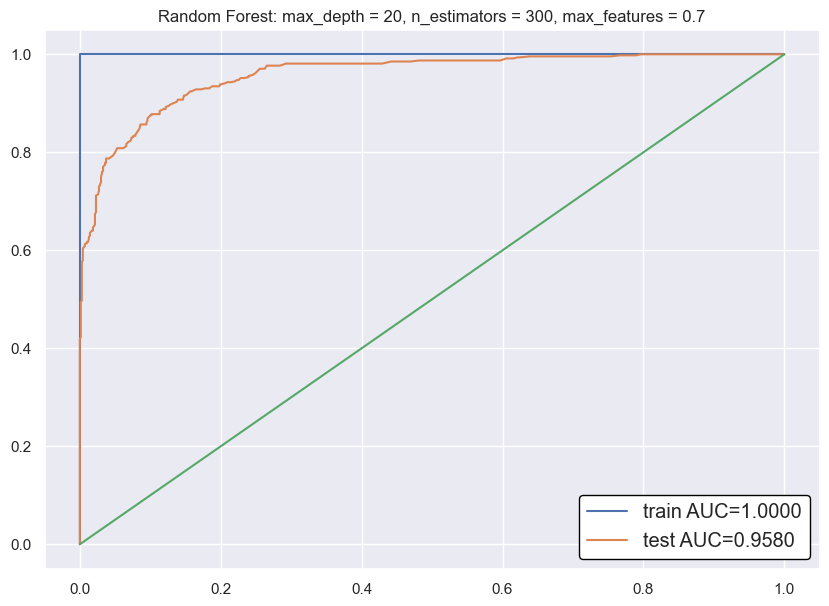

In [123]:
y_train_pred = y_tp_f
y_valid_pred = y_vp_f
train_auc = roc_auc_score(y_train, y_train_pred)
test_auc = roc_auc_score(y_valid, y_valid_pred)

plt.figure(figsize=(10,7))
plt.plot(*roc_curve(y_train, y_train_pred)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_valid, y_valid_pred)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.title(f'Random Forest: max_depth = {max_d}, n_estimators = {n_est}, max_features = {max_f}')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12788\412872217.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


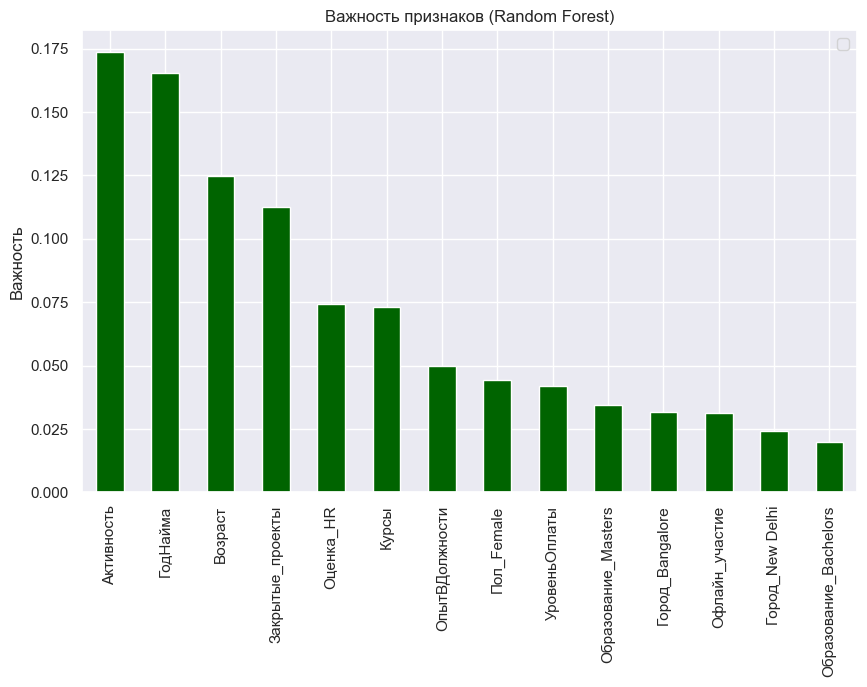

In [122]:
# Визуализация важности
importances = pd.Series(clf_forest.feature_importances_, index=X_train[cols_num].columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='darkgreen')
plt.title('Важность признаков (Random Forest)')
plt.ylabel('Важность')
# plt.axhline(y=0.01, color='r', linestyle='--', label='Порог важности (0.01)')
plt.legend()
plt.show()

In [41]:
# Удаляем неинформативные признаки
to_keep = importances[importances > 0.025].index
X_train_imp = X_train[to_keep]
X_valid_imp = X_valid[to_keep]
X_test_imp = X_test[to_keep]

ROC_AUC_upd = evaluate_model(clf_forest, X_train_imp, X_valid_imp, y_train, y_valid)
print(f"ROC-AUC после отбора по важности: {ROC_AUC_upd}")
# probabilities = clf_forest.predict_proba(X_test_imp)[:, 1]

ROC-AUC после отбора по важности: (1.0, 0.941369712411001)


#### Catboost model

In [151]:
max_d = 10
n_est = 100
l_rate = 0.7

# cols_obj = list(X_train.select_dtypes(include=['object']).columns)

clf_catboost = CatBoostClassifier(max_depth=max_d, n_estimators=n_est, learning_rate=l_rate, verbose=False, random_state=42)
clf_catboost.fit(X_train[cols_num], y_train)
y_tp_c = clf_catboost.predict_proba(X_train[cols_num])[:, 1]
y_vp_c = clf_catboost.predict_proba(X_valid[cols_num])[:, 1]

print(
    f'Train: {roc_auc_score(y_train, y_tp_c)}\n'
    f'valid: {roc_auc_score(y_valid, y_vp_c)}\n'
)

# Предсказание вероятностей
# probabilities = clf_catboost.predict_proba(X_test)[:, 1]

Train: 1.0
valid: 0.9600422864909763



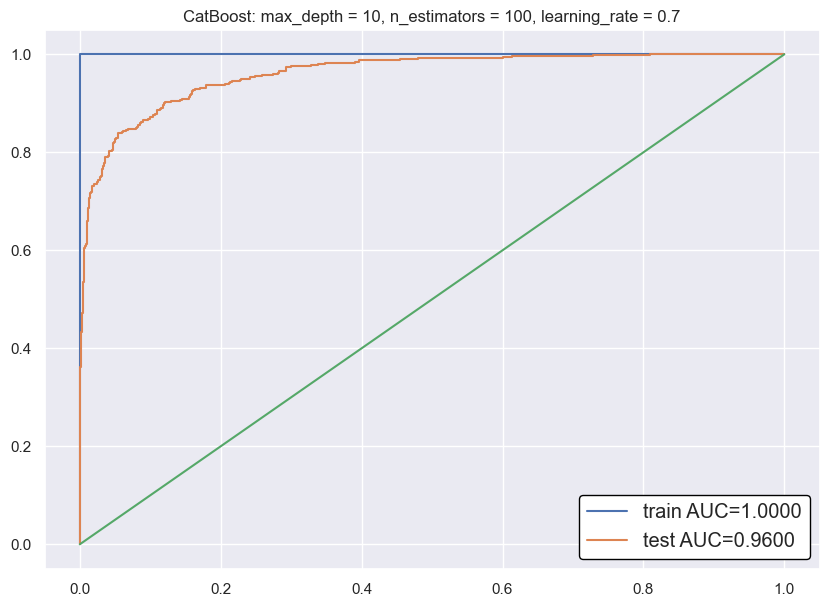

In [150]:
y_train_pred = y_tp_c
y_valid_pred = y_vp_c
train_auc = roc_auc_score(y_train, y_train_pred)
test_auc = roc_auc_score(y_valid, y_valid_pred)

plt.figure(figsize=(10,7))
plt.plot(*roc_curve(y_train, y_train_pred)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_valid, y_valid_pred)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.title(f'CatBoost: max_depth = {max_d}, n_estimators = {n_est}, learning_rate = {l_rate}')
plt.show()

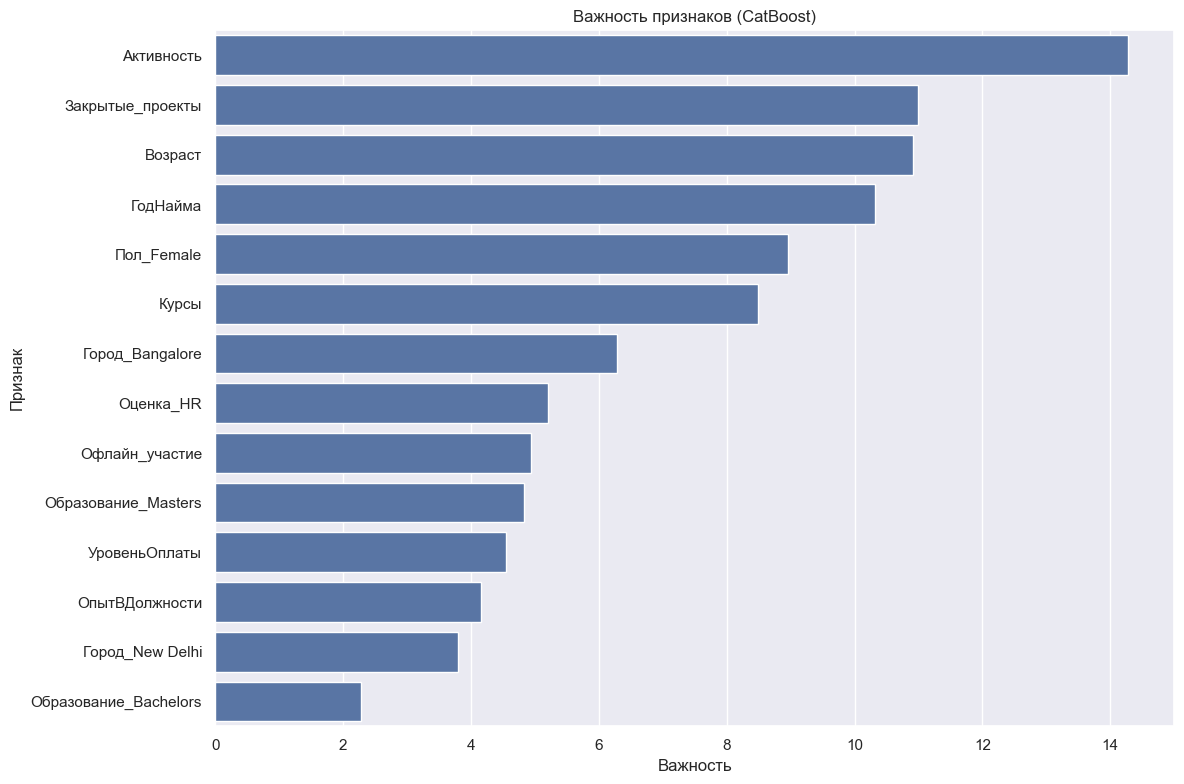

In [153]:
# Получение важности признаков
feature_importances = clf_catboost.get_feature_importance()
feature_names = cols_num

# Создание DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Важность признаков (CatBoost)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

In [ ]:
# Удаляем неинформативные признаки
to_keep = importance_df[importance_df.Importance > 3].Feature.to_list()
X_train_imp = X_train[to_keep]
X_valid_imp = X_valid[to_keep]
X_test_imp = X_test[to_keep]

ROC_AUC_upd = evaluate_model(clf_catboost, X_train_imp, X_valid_imp, y_train, y_valid)
print(f"ROC-AUC после отбора по важности: {ROC_AUC_upd}")
# probabilities = clf_catboost.predict_proba(X_test_imp)[:, 1]

ROC-AUC после отбора по важности: (0.9998537877510422, 0.918816022150868)


#### Выводы

Для решения задачи были построены три модели: Логистическая регрессия, случайный лес и CatBoost.

* Регрессия показала самый низкий результат на valid set по ROC-AUC = 0.71.
* RandomForest (max_depth = 20, n_estimators = 300, max_features = 0.7) показал ROC-AUC = 0.958 на valid set и ROC-AUC = 0.92 на тестовой выборке. 
* CatBoost (max_depth = 10, n_estimators = 100, learning_rate = 0.7) показал схожий результат с RandomForest ROC-AUC = 0.960 на valid set. На тестовой выборке проверить не удалось в виду завершения попыток на Codabench.
* После исключения строк по работникам оставшимся в компании и с уровнем оплаты ниже 3 на RandomForest ROC-AUC = 0.97. Вероятно данный сценарий показал бы более высокое значение по ROC-AUC на тестовой выборке.

В результате, финальные вероятности и ROC-AUC = 0.92 на тесте были получены с помощью RandomForest на дата сете без фильтрации по УровнюОплаты.